Trong file Google Colab này, mình sẽ chia thành 3 layers: 
1. Tầng 1 (PPG raw)
2. Tầng 2 (IMU Magnitude raw)
3. Tầng 3 (Correlation check)

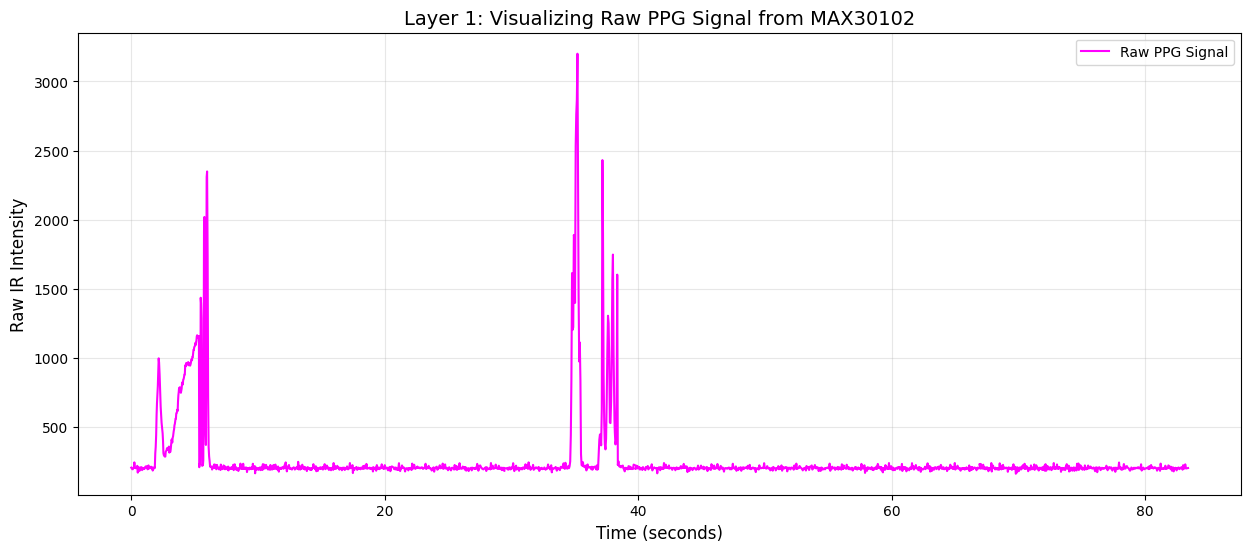

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load file CSV
file_path = r"C:\Users\Admin\Downloads\draft_one_signal_final_project\3rd_raw_data.csv"
df = pd.read_csv(file_path)

# --- BƯỚC QUAN TRỌNG: CHUYỂN ĐỔI SANG DẠNG SỐ ---
# errors='coerce' sẽ giúp chuyển các dòng lỗi (nếu có) thành NaN để tránh sập code
df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')
df['Heart_IR'] = pd.to_numeric(df['Heart_IR'], errors='coerce')

# Loại bỏ các dòng bị trống (NaN) sau khi chuyển đổi
df = df.dropna()

# 2. Xử lý Timestamp (Tính thời gian trôi qua)
# Bây giờ phép trừ này sẽ hoạt động vì cả hai đều là số (float)
df['Time_Seconds'] = df['Timestamp'] - df['Timestamp'].iloc[0]

# 3. Visualize Raw Data
plt.figure(figsize=(15, 6))
plt.plot(df['Time_Seconds'], df['Heart_IR'], color='magenta', label='Raw PPG Signal')
plt.title("Layer 1: Visualizing Raw PPG Signal from MAX30102", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Raw IR Intensity", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**Phân tích dữ liệu PPG thô từ cảm biến MAX30102**

Dựa trên đồ thị dữ liệu thô (Raw Data Plot), mình có 3 quan sát chính:
1. Về cường độ (Intensity): 

Các đỉnh nhiễu (peaks) xuất hiện ở mức $2500 - 3000$ đơn vị. Thực tế, con số này rất thấp so với mức hoạt động bình thường của MAX30102 (thường $> 30,000$ khi có tiếp xúc tốt). Điều này cho thấy đây không phải lỗi Clipping, mà khả năng cao là tín hiệu khi cảm biến không tiếp xúc chặt với da hoặc bị lọt sáng (Ambient light leakage).

2. Về chu kỳ sinh lý (Physiology Check): 

Hai đỉnh lớn nhất cách nhau tới 30 giây. Theo logic y sinh, nhịp tim người không bao giờ chậm như vậy ($2$ nhịp/phút), khẳng định các peaks này hoàn toàn là nhiễu ngoại vi (Artifacts), không phải nhịp tim.

3. Về đặc trưng tín hiệu (Signal Pattern): 

Phần lớn dữ liệu không có quy luật (patterns), chỉ gồm các dao động nhiễu biên độ nhỏ ở phía dưới. Nhịp tim thật đang bị che lấp hoàn toàn bởi các nhiễu này.

**Next steps**

Mình vẽ thêm 3 plots bổ trợ để "bắt bệnh" cụ thể cho 4 vấn đề: 
1. Motion Artifacts (Nhiễu do chuyển động)
    * xảy ra khi sensor bị xê dịch khỏi da
    * solution: dùng IMU làm tham chiếu
    => next steps: 
        * tức là cần vẽ plot IMU raw signal
        * sau đó so sánh các đỉnh của 2 plots với nhau, xem có khớp không
2. Baseline Wander (Trôi đường cơ sở)
    * xảy ra khi plot nhịp tim không nằm ngang mà cứ lượn sóng lên xuống chậm rãi (dự đoán: data của mình ko có vấn đề đấy)
    * nếu có -> solution: dùng Highpass filter

3. Power Line Interference (Nhiễu điện 50Hz)
    * xảy ra khi các răng cưa li ti xuất hiện đều đặn trên sóng. Tức đang bị nhiễu bởi các thiết bị điện khác trong phòng (có tần số 50-60 Hz)
    * dự đoán: data của mình gặp vấn đề này 
    * solution: dùng Lowpass Filter (Or apply Moving Average)

4. Ambient Light 
    * xảy ra khi lọt ánh sáng từ môi trường vào -> khiến dữ liệu bị saturated 
    * dự đoán: data đang ko gặp vấn đề này
    * solution: fix hardware + thêm vào phần setup() trong code
    * nhưng hiện tại mình ưu tiên fix những vấn đề bên trên trước

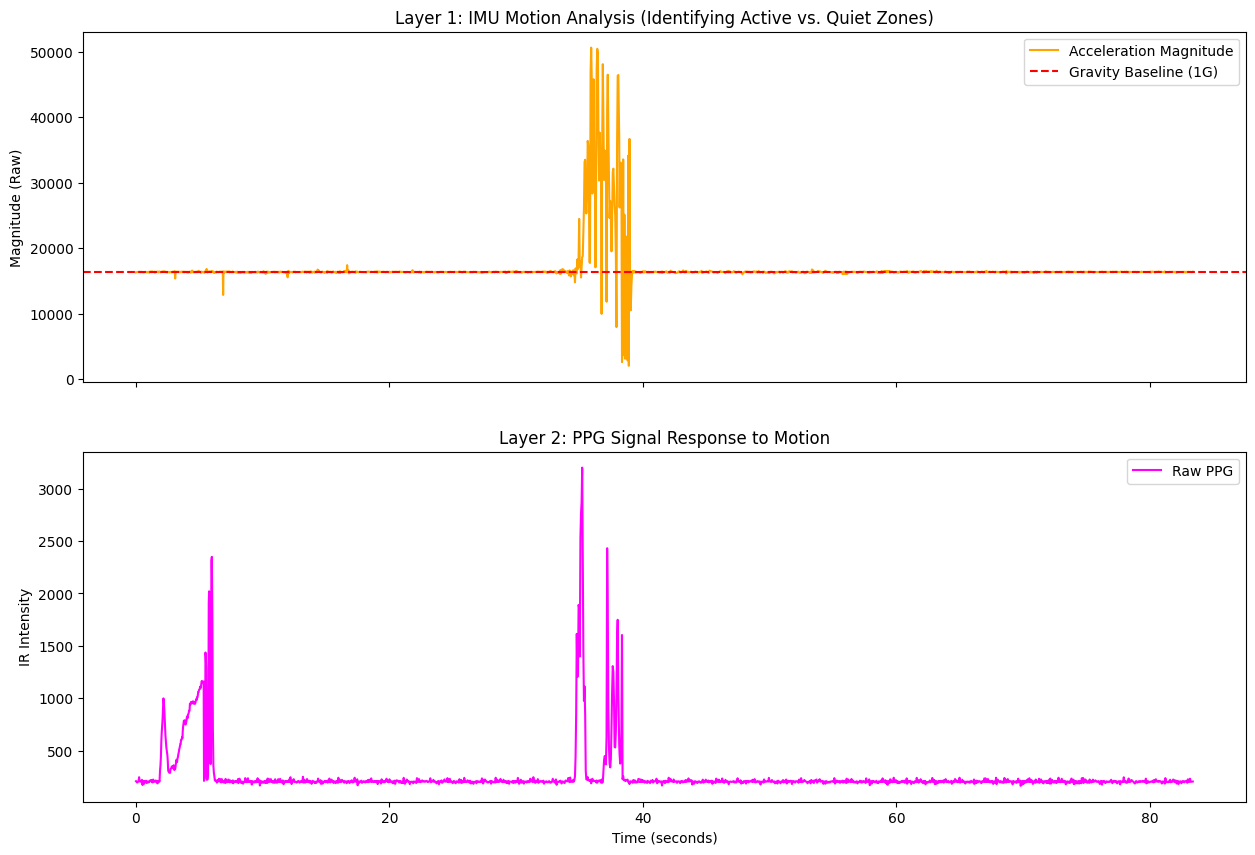

In [6]:
# Tính Magnitude |A|
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# Vẽ đồ thị so sánh
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot 1: IMU Magnitude (Để xem khi nào tay chuyển động)
ax1.plot(df['Time_Seconds'], df['Acc_Mag'], color='orange', label='Acceleration Magnitude')
ax1.axhline(y=16384, color='r', linestyle='--', label='Gravity Baseline (1G)')
ax1.set_title("Layer 1: IMU Motion Analysis (Identifying Active vs. Quiet Zones)")
ax1.set_ylabel("Magnitude (Raw)")
ax1.legend()

# Plot 2: PPG Signal (Để xem nhiễu có khớp với chuyển động không)
ax2.plot(df['Time_Seconds'], df['Heart_IR'], color='magenta', label='Raw PPG')
ax2.set_title("Layer 2: PPG Signal Response to Motion")
ax2.set_ylabel("IR Intensity")
ax2.set_xlabel("Time (seconds)")
ax2.legend()

plt.show()

**Phân tích dữ liệu IMU Magnitude Raw**

1. data có peak ở 50000. Mình có thể nhìn thấy data đang bị san phẳng khi đạt đến cực trị max => data (đầu vào) vẫn đang bị clipping. 
Bây giờ mình sẽ thử xử lý data đầu vào bị clipping. Rồi ở lần tới thu tập dataset mới, mình sẽ nâng code lên full-scale capture (từ +- 2g/bit lên +- 16g/bit) sau.

2. có nhiều cái peak tập trung ở cùng 1 điểm, chứng tỏ chỗ đó người dùng đang đấm liên tục.

3. nhưng khi so với plot PPG raw thì thấy không khớp (về peaks), và ta có thể thấy là ở 10s đầu của IR signal, những peak là nhiễu chứ chưa phải nhịp tim thật.

**Dự đoán vấn đề data đang có**

Bây giờ tớ sẽ thử suy ra các trường cái IMU signal này có thể có vấn đề nhé:

1. random noise:
    * xảy ra khi các đường đồ thị bị răng cưa khi mạch đang nằm im
    * dự đoán: data của mình không bị
    * solution: apply lowpass filter (nếu muốn data đẹp hơn)


2. 0-offset bias
    * xảy ra người dùng đang đứng im, mà giá trị (trên x and y-axis) không về 0 
    * dự đoán: data có bị
    * solution: ứng dụng calibration: tính giá trị trung bình khi nằm in rồi trừ nó ra trong code ( ax = raw - offset)
    * note: công thức tính offset: 
        Offset của X = Average(AccX_tĩnh).

        Offset của Y = Average(AccY_tĩnh).

        Offset của Z = Average(AccZ_tĩnh) - 16384 (vì Z phải giữ lại 1G trọng lực).

        Sau đó, mọi dữ liệu sau này chỉ việc: AccX_thật = AccX_raw - Offset_X


3. signal clipping
    * xảy ra khi data lên tới mức trên tốc độ mà code xử lý được, nên những giá trị cao nhất bị san phẳng
    * dự đoán: data bị 
    * solution: thay đổi code ở file main.cpp ở lần tới thu data 

4. gyro drift
    * xảy ra khi user xoay tay rồi dừng lại, mà giá trị Gyro không về 0 ngay, hoặc bị trôi dần (drift) 
    * hiện tại trong data của tớ chưa có gyro nên tớ chưa biết nhận xét cái này

5. mechanical resonance
    * xảy ra khi đồ thị rung bần bật khi user va chạm mạnh (ví dụ: ngã xuống đất)
    * project này tụi tớ chỉ định aim đấm khi đứng thẳng thôi, nên chắc tạm bỏ qua cái này đã

**LAYER 3: CORRELATION CHECK**

* Làm bước này để đưa PPG và Magintude về chung 1 thang đo (từ 0 đến 1) và quan sát vấn đề của 2 data luôn. 

* Đưa 2 con số về chung 1 thang đo bằng công thức Normalization (nổi tiếng trong Machine Learning). Nó sẽ đi qua các bước sau:
1. Tiền xử lý PPG: Lấy Heart_IR, trừ đi giá trị nhỏ nhất (min), sau đó chia cho (max - min). Kết quả sẽ là một dải dữ liệu chạy từ $0$ đến $1$.

2. Tiền xử lý IMU: Lấy Acc_Mag, trừ đi $16384$ (Baseline 1G), sau đó cũng chia cho (max - min) để đưa về dải $0$ đến $1$.

3. Vẽ đè lên nhau: Dùng chung một trục $X$ (Thời gian) và cùng một trục $Y$ (Biên độ đã chuẩn hóa).


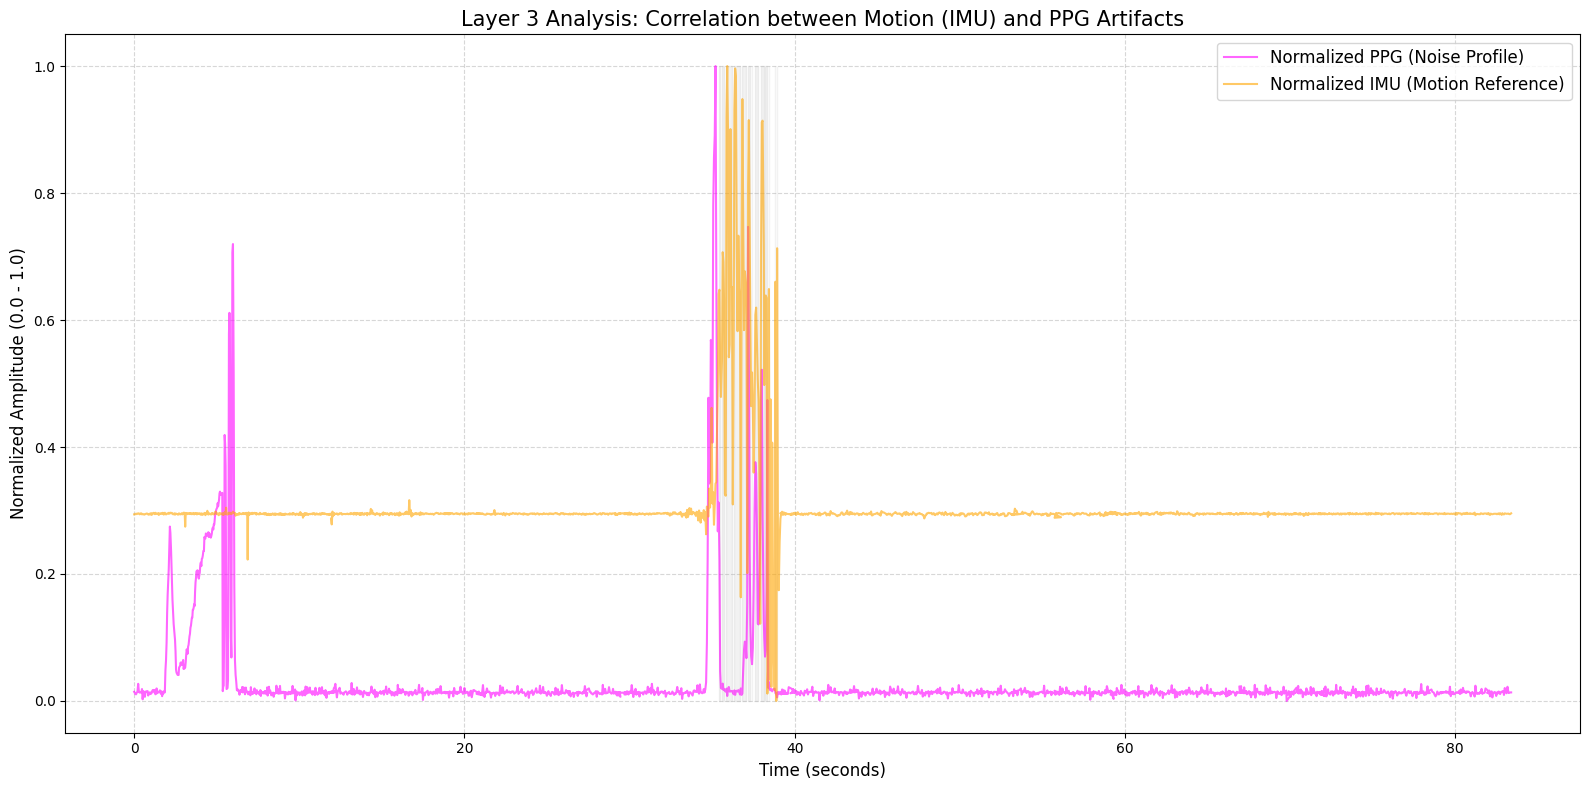

In [4]:
# Ép kiểu dữ liệu sang số để tránh lỗi 'str' and 'str'
cols = ['Timestamp', 'AccX', 'AccY', 'AccZ', 'Heart_IR']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna() # Loại bỏ các dòng lỗi

# 2. Tính toán Feature Engineering
# Chuyển timestamp về giây bắt đầu từ 0
df['Time_Seconds'] = df['Timestamp'] - df['Timestamp'].iloc[0]

# Tính Magnitude của IMU (Công thức chuẩn Engineer) [cite: 2026-04-08]
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# 3. Áp dụng công thức Normalization (Min-Max Scaling) [cite: 2026-04-08]

# Chuẩn hóa PPG (0 -> 1)
ppg_min = df['Heart_IR'].min()
ppg_max = df['Heart_IR'].max()
df['PPG_Norm'] = (df['Heart_IR'] - ppg_min) / (ppg_max - ppg_min)

# Chuẩn hóa IMU (0 -> 1) - Dựa trên độ lệch so với Gravity Baseline (16384) [cite: 2026-04-08]
imu_offset = df['Acc_Mag'] - 16384
imu_min = imu_offset.min()
imu_max = imu_offset.max()
df['IMU_Norm'] = (imu_offset - imu_min) / (imu_max - imu_min)

# 4. Vẽ đồ thị Layer 3: Correlation Check
plt.figure(figsize=(16, 8))

# Vẽ PPG (Màu tím đặc trưng của Giang)
plt.plot(df['Time_Seconds'], df['PPG_Norm'], label='Normalized PPG (Noise Profile)', color='magenta', alpha=0.6, linewidth=1.5)

# Vẽ IMU (Màu cam để thấy sự chuyển động)
plt.plot(df['Time_Seconds'], df['IMU_Norm'], label='Normalized IMU (Motion Reference)', color='orange', alpha=0.6, linewidth=1.5)

# Trang trí đồ thị chuyên nghiệp để báo cáo
plt.title("Layer 3 Analysis: Correlation between Motion (IMU) and PPG Artifacts", fontsize=15)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Normalized Amplitude (0.0 - 1.0)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=12)

# Highlight vùng nhiễu tiềm năng (Vùng có gia tốc lớn)
plt.fill_between(df['Time_Seconds'], 0, 1, where=(df['IMU_Norm'] > 0.5), color='gray', alpha=0.1, label='High Motion Zone')

plt.tight_layout()
plt.show()

Ở plot trên, nhìn bằng mắt thường, mình thấy 1 vài điểm lạ sau: 
1. đường màu cam hoặc hồng, tăng vọt lên mà không thấy đường còn lại 
2. đường PPG tăng trước xong đường IMU mới tăng thì sao (trong khi lẽ ra đường IMU phải tăng trước rồi PPG mới tăng)

=> thay vì reasoning bằng mắt thường và lý lẽ, tớ dùng cái code tính Pearson Correlation Coefficient dưới đây: 

    * r ~ 1.0: Hai đường cực kỳ khớp nhau. Khẳng định 100% PPG bị nhiễu do IMU.

    * r ~ 0: Hai đường không liên quan gì nhau. Nhiễu của PPG đến từ nguồn khác (điện lưới hoặc ánh sáng), không phải do chuyển động.

    * r < 0 (Nghịch biến): Càng di chuyển mạnh thì PPG càng tụt (thường do cảm biến bị hở ra khi vung tay).


--- KẾT QUẢ PHÂN TÍCH ---
Hệ số tương quan tổng thể (r): 0.1841


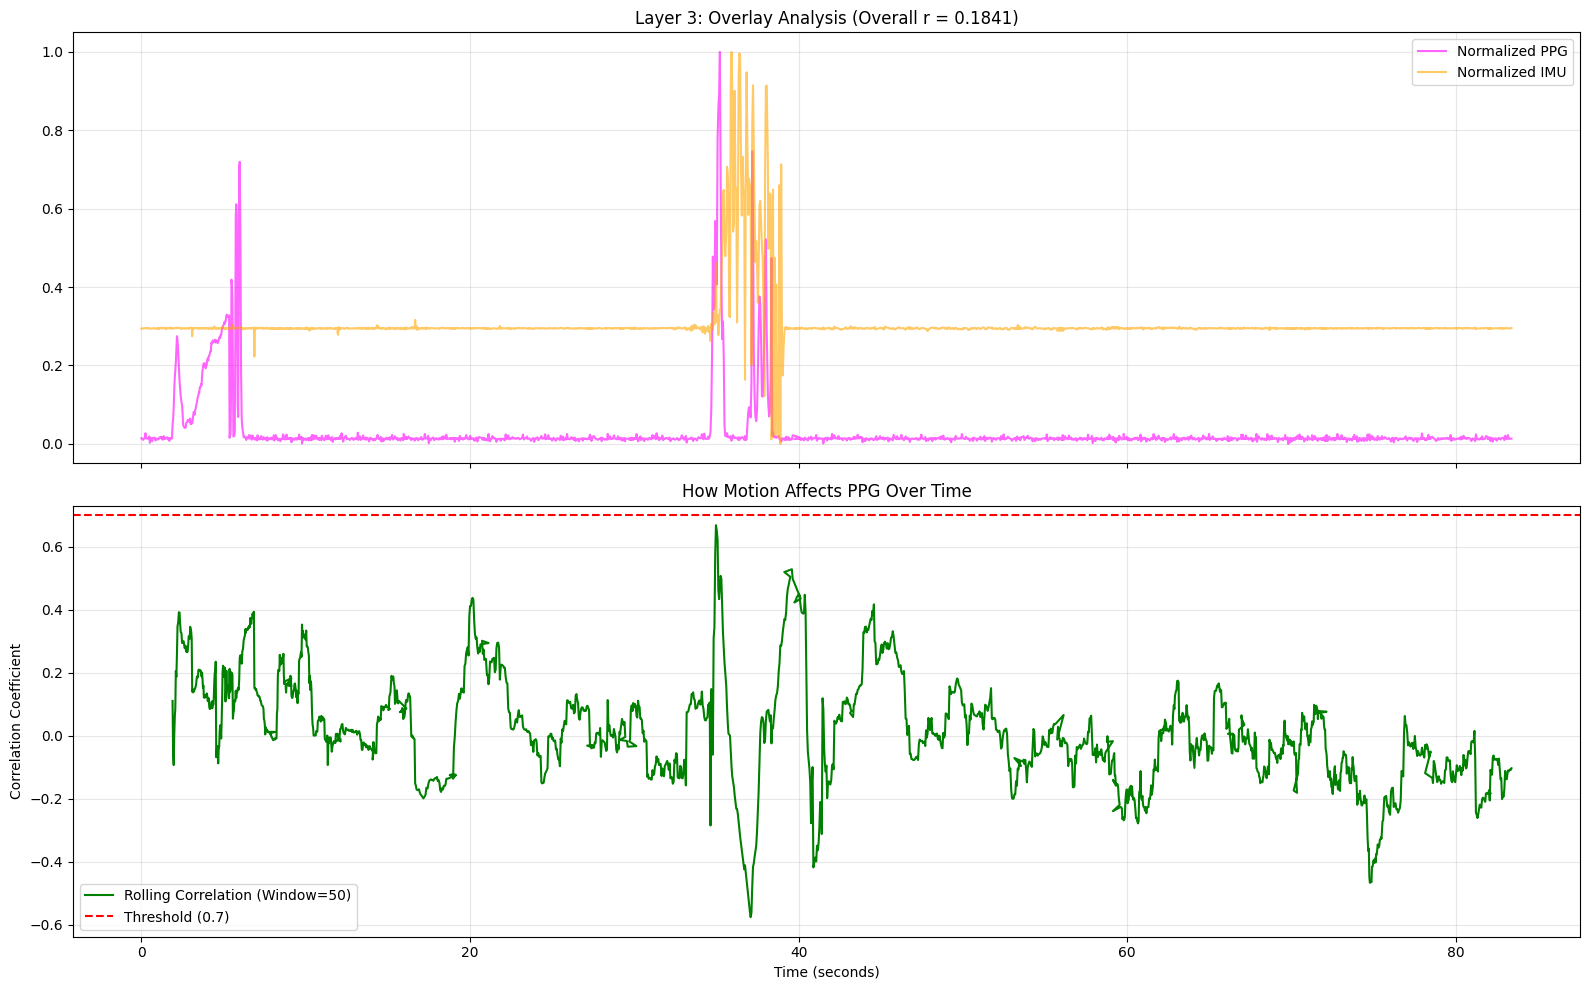

In [11]:
# 2. Ép kiểu và làm sạch (Rất quan trọng!)
cols = ['Timestamp', 'AccX', 'AccY', 'AccZ', 'Heart_IR']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# 3. Tính toán các cột cần thiết
df['Time_Seconds'] = df['Timestamp'] - df['Timestamp'].iloc[0]
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# --- BƯỚC NÀY TẠO RA 'PPG_Norm' VÀ 'IMU_Norm' ---
# Chuẩn hóa PPG
ppg_min, ppg_max = df['Heart_IR'].min(), df['Heart_IR'].max()
df['PPG_Norm'] = (df['Heart_IR'] - ppg_min) / (ppg_max - ppg_min)

# Chuẩn hóa IMU (so với baseline 1G)
imu_diff = df['Acc_Mag'] - 16384
imu_min, imu_max = imu_diff.min(), imu_diff.max()
df['IMU_Norm'] = (imu_diff - imu_min) / (imu_max - imu_min)

# 4. Tính Correlation (Hệ số tương quan Pearson)
correlation = df['PPG_Norm'].corr(df['IMU_Norm'])

print(f"--- KẾT QUẢ PHÂN TÍCH ---")
print(f"Hệ số tương quan tổng thể (r): {correlation:.4f}")

# 5. Tính Rolling Correlation (Tương quan trượt)
df['Rolling_Corr'] = df['PPG_Norm'].rolling(window=50).corr(df['IMU_Norm'])

# 6. Vẽ đồ thị tổng hợp
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Overlay PPG and IMU
ax1.plot(df['Time_Seconds'], df['PPG_Norm'], label='Normalized PPG', color='magenta', alpha=0.6)
ax1.plot(df['Time_Seconds'], df['IMU_Norm'], label='Normalized IMU', color='orange', alpha=0.6)
ax1.set_title(f"Layer 3: Overlay Analysis (Overall r = {correlation:.4f})")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Rolling Correlation
ax2.plot(df['Time_Seconds'], df['Rolling_Corr'], color='green', label='Rolling Correlation (Window=50)')
ax2.axhline(y=0.7, color='r', linestyle='--', label='Threshold (0.7)')
ax2.set_title("How Motion Affects PPG Over Time")
ax2.set_ylabel("Correlation Coefficient")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sampling Rate (fs): 23.93 Hz


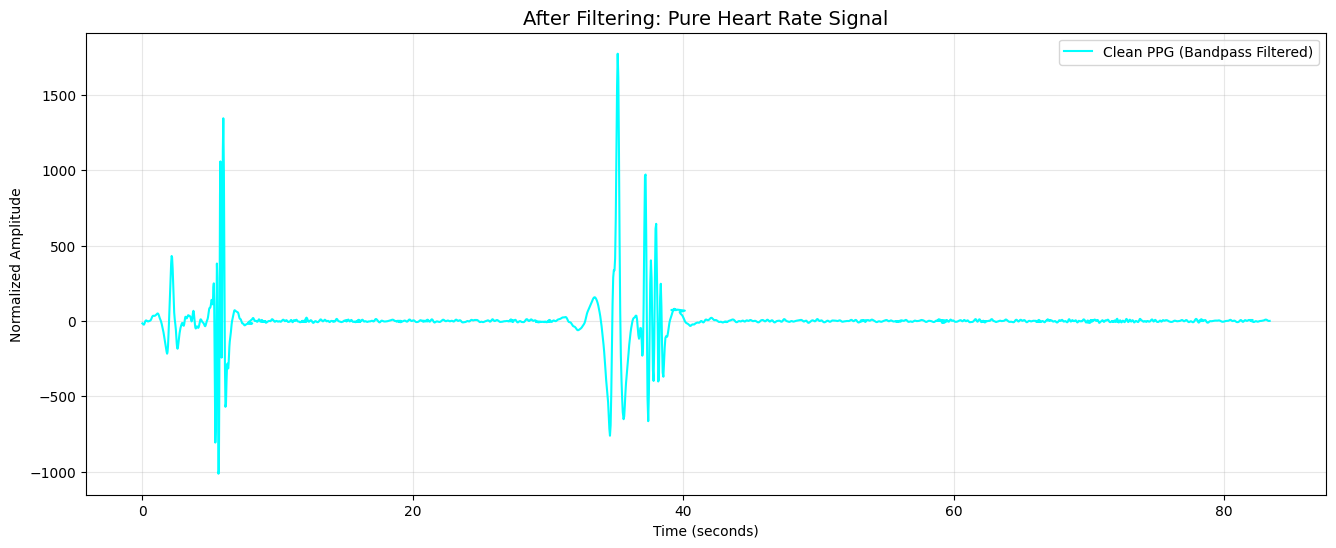

In [12]:
# Butterworth Bandpass Filter
from scipy import signal

# 1. Xác định Tần số lấy mẫu (Sampling Rate - fs)
# Đây là bước cực quan trọng! fs = số mẫu thu được trong 1 giây.
time_diff = df['Time_Seconds'].diff().mean()
fs = 1 / time_diff 
print(f"Sampling Rate (fs): {fs:.2f} Hz")

# 2. Thiết lập thông số bộ lọc
lowcut = 0.5   # Loại bỏ nhiễu dưới 0.5Hz (30 BPM) - khử Baseline Wander
highcut = 4.0  # Loại bỏ nhiễu trên 4.0Hz (240 BPM) - khử High-frequency Noise
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

# 3. Tạo bộ lọc Butterworth (b, a là các hệ số toán học của bộ lọc)
b, a = signal.butter(4, [low, high], btype='band') # Order 4 là đủ mạnh rồi

# 4. Áp dụng lọc (Dùng filtfilt để không bị lệch pha tín hiệu)
df['PPG_Filtered'] = signal.filtfilt(b, a, df['Heart_IR'])

# 5. Vẽ đồ thị so sánh
plt.figure(figsize=(16, 6))
plt.plot(df['Time_Seconds'], df['PPG_Filtered'], color='cyan', label='Clean PPG (Bandpass Filtered)')
plt.title("After Filtering: Pure Heart Rate Signal", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Data trên dở tệ -> Có 3 "nghi phạm" chính mà mình dự đoán:

* Nghi phạm 1: Tần số lấy mẫu ($fs$) bị sai. 

    * Trong code AI đưa, $fs$ được tính bằng 1 / df['Time_Seconds'].diff().mean().
    * Vấn đề: Nếu dữ liệu có những đoạn bị trễ (delay) hoặc mất mẫu (dropped frames) khi gửi từ ESP32 qua Serial, con số $fs$ này sẽ bị sai lệch hoàn toàn. Nếu $fs$ sai, các hệ số của bộ lọc Butterworth sẽ "đi viện", dẫn đến việc nó lọc nhầm vào dải nhiễu thay vì nhịp tim.

* Nghi phạm 2: Bậc của bộ lọc (Order) quá cao. Code đang để Order 4. 

Với dữ liệu nhiễu cực mạnh và $fs$ không ổn định, bộ lọc bậc cao dễ bị "ringing" (dao động tự thân).

* Nghi phạm 3: Dữ liệu Raw không có nhịp tim.Cậu nhìn lại đoạn 0s - 35s ở đồ thị trước. 

Đường PPG tím gần như là một đường thẳng có nhiễu li ti. Khi mình cố "ép" một bộ lọc Bandpass vào một đường thẳng chỉ có nhiễu, nó sẽ cố gắng phóng đại những gợn sóng nhiễu nhỏ nhất đó lên để lấp đầy dải tần 0.5 - 4Hz. Kết quả là mình nhận được một "đống rác" được phóng đại.